# AeroSonicDB vs Skatval aircraft event comparison

This notebook finds one aircraft event in AeroSonicDB and one aircraft event in Skatval, then compares their waveforms and spectrograms side by side.

In [ ]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import librosa
import librosa.display as librosa_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'dataset' / 'AeroSonicDB' / 'gt_train.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root from the current working directory.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import settings
from keras_yamnet import params
from keras_yamnet.preprocessing import bandpass_filter, preprocess_input

SKATVAL_ROOT = PROJECT_ROOT / 'dataset' / 'Skatval'
AERO_GT_FILE = PROJECT_ROOT / 'dataset' / 'AeroSonicDB' / 'gt_train.csv'

# Configurable radius for the Skatval selection.
SKATVAL_RADIUS_KM = 2.0
# Set this to 'bandpass' if you want the waveform plot and mel spectrogram to use the bandpass filter.
PREPROCESS_FILTER = None
# Fixed seed so the AeroSonicDB per-fold random choice is reproducible.
AERO_RANDOM_SEED = 32

# Figure styling controls for every plot in this notebook.
FIGURE_FONT_FAMILY = 'Times New Roman'
FIGURE_FONT_SIZE = 25
FIGURE_LABEL_SIZE = 25
FIGURE_TICK_SIZE = 25
FIGURE_PANEL_WIDTH = 3.5
WAVEFORM_FIG_HEIGHT = 3.4
SPECTROGRAM_FIG_HEIGHT = 3.8

plt.rcParams.update({
    'font.family': FIGURE_FONT_FAMILY,
    'font.size': FIGURE_FONT_SIZE,
    'axes.labelsize': FIGURE_LABEL_SIZE,
    'xtick.labelsize': FIGURE_TICK_SIZE,
    'ytick.labelsize': FIGURE_TICK_SIZE,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def env_path(name: str) -> Path | None:
    value = os.getenv(name)
    return Path(value) if value else None


AERO_AUDIO_ROOT_CANDIDATES = [
    env_path('AERO_AUDIO_ROOT'),
    env_path('SED_DATASETS_FOLDER'),
    settings.audio_folder_aero,
    Path(r'C:/Users/imborhau/OneDrive - NTNU/Documents/Prosjektoppgave/AeroSonicDB-YPAD0523/data/raw'),
]


def resolve_audio_root(candidates: list[Path | None]) -> Path:
    for candidate in candidates:
        if candidate is not None and candidate.exists():
            return candidate
    raise FileNotFoundError(
        'Could not locate the AeroSonicDB audio root. Set AERO_AUDIO_ROOT or SED_DATASETS_FOLDER to the folder containing audio/0 and audio/1.'
    )


AERO_AUDIO_ROOT = resolve_audio_root(AERO_AUDIO_ROOT_CANDIDATES)
AERO_AUDIO_DIRS = [AERO_AUDIO_ROOT / 'audio' / '0', AERO_AUDIO_ROOT / 'audio' / '1']

print(f'Project root: {PROJECT_ROOT}')
print(f'AeroSonicDB audio root: {AERO_AUDIO_ROOT}')
print(f'Skatval root: {SKATVAL_ROOT}')


Project root: c:\Users\imborhau\Documents\sound-event-detection-aircrafts
AeroSonicDB audio root: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw
Skatval root: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval


In [183]:
from src.preprocessing import AudioLoader, YAMNetFeatureExtractor
loader = AudioLoader()
extractor = YAMNetFeatureExtractor(apply_filter=None)
import pickle
import tensorflow as tf

# Map Skatval session folder names to session numbers for plot titles.
SKATVAL_SESSION_MAP = {
    '280126': 1,
    '230226': 2,
    '030326': 3,
    '260326_part': 4,
    '300925': 5,
}

# Group Skatval folders that should count as a single session.
# The order here controls the left-to-right plot order.
SKATVAL_SESSION_GROUPS = [
    ('280126', ['280126']),
    ('230226', ['230226']),
    ('030326', ['030326']),
    ('260326_part', ['260326_part1', '260326_part2']),
    ('300925', ['300925']),
]

def load_table(path: Path) -> pd.DataFrame:
    table = pd.read_csv(path, sep=None, engine='python')
    table = table.copy()
    for column in ['start_time', 'end_time', 'class', 'fold', 'location']:
        if column in table.columns:
            table[column] = pd.to_numeric(table[column], errors='coerce')
    return table.dropna(subset=['start_time', 'end_time', 'class'])


def resolve_audio_file(filename: str, roots: list[Path]) -> Path:
    for root in roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        for match in root.rglob(filename):
            return match
    raise FileNotFoundError(f'Could not find {filename} under any of: {roots}')


def load_audio_segment(path: Path, start_s: float, end_s: float, pad_s: float = 2.0) -> tuple[np.ndarray, int, float, float]:
    info = sf.info(str(path))
    sample_rate = info.samplerate
    window_start = max(0.0, start_s - pad_s)
    window_end = min(info.frames / sample_rate, end_s + pad_s)
    start_frame = int(round(window_start * sample_rate))
    stop_frame = int(round(window_end * sample_rate))
    if stop_frame <= start_frame:
        stop_frame = min(info.frames, start_frame + sample_rate)
    audio, _ = sf.read(str(path), start=start_frame, stop=stop_frame, dtype='int16', always_2d=False)
    if audio.ndim > 1:
        audio = audio[:, 0]
    return audio, sample_rate, window_start, window_end


def preprocess_waveform_for_plot(waveform: np.ndarray, sample_rate: int, apply_filter: str | None = PREPROCESS_FILTER) -> tuple[np.ndarray, int]:
    assert waveform.dtype == np.int16, f'Bad sample type: {waveform.dtype!r}'
    waveform = waveform / np.iinfo(np.int16).max
    waveform = waveform.astype(np.float32)

    if sample_rate != params.SAMPLE_RATE:
        waveform = librosa.resample(waveform, orig_sr=sample_rate, target_sr=params.SAMPLE_RATE, axis=0)

    if apply_filter == 'bandpass':
        waveform = bandpass_filter(waveform)
    elif apply_filter is not None:
        raise ValueError(f'Unknown apply_filter value: {apply_filter}')

    return waveform, params.SAMPLE_RATE


def longest_skatval_event(csv_paths: list[Path], session_name: str, radius_km: float, class_label: int, duration_cap: float = None, target_duration: float = None) -> dict[str, object] | None:
    candidate_rows: list[pd.DataFrame] = []
    for csv_path in csv_paths:
        table = load_table(csv_path)
        positives = table[table['class'] == class_label].copy()
        if positives.empty:
            continue
        positives['csv_path'] = str(csv_path)
        positives['duration_s'] = positives['end_time'] - positives['start_time']
        candidate_rows.append(positives)

    if not candidate_rows:
        return None

    all_positives = pd.concat(candidate_rows, ignore_index=True)

    if duration_cap is not None:
        all_positives_under_cap = all_positives[all_positives['duration_s'] <= duration_cap]
        if all_positives_under_cap.empty:
            first_row = all_positives.iloc[0]
            print(f'Capping first positive event in session {session_name} at radius {radius_km} km to {duration_cap} seconds (original duration: {first_row["duration_s"]:.2f} seconds)')
            all_positives.loc[0, 'duration_s'] = duration_cap
        else:            
            all_positives = all_positives_under_cap


    tolerance = 10  # seconds

    candidate_rows = all_positives[
        (all_positives['duration_s'] >= target_duration - tolerance) &
        (all_positives['duration_s'] <= target_duration + tolerance)
    ]
    if candidate_rows.empty:
        candidate_rows = all_positives
        
    row = candidate_rows.sample(
        n=1,
        random_state=AERO_RANDOM_SEED
    ).iloc[0]
    audio_path = Path(str(row['csv_path'])).parent.parent / str(row['filename'])
    if not audio_path.exists():
        return None
    return {
        'dataset': 'Skatval',
        'group_type': 'session',
        'group_label': f'{session_name} · {radius_km:g} km',
        'session': session_name,
        'radius_km': radius_km,
        'gt_path': Path(str(row['csv_path'])),
        'audio_path': audio_path,
        'filename': str(row['filename']),
        'start_time': float(row['start_time']),
        'end_time': float(row['end_time']),
        'class': int(row['class']),
        'event_id': str(row['event_id']),
        'callsign': '' if pd.isna(row.get('callsign')) else str(row.get('callsign')),
        'distance': float(row['distance']) if pd.notna(row.get('distance')) else None,
        'fr24_id': '' if pd.isna(row.get('fr24_id')) else str(row.get('fr24_id')),
    }


def collect_skatval_examples(radius: float, class_label: int, target_duration: float) -> list[dict[str, object]]:
    # Use a single radius (float). If a session has no positive event at this radius,
    # print a message and skip that session.
    radius = float(radius)
    radius_token = f'{radius:.1f}'
    examples: list[dict[str, object]] = []
    for session_name, session_folders in SKATVAL_SESSION_GROUPS:
        csv_paths: list[Path] = []
        for folder_name in session_folders:
            session_root = SKATVAL_ROOT / folder_name
            if not session_root.exists():
                continue
            csv_paths.extend(sorted(session_root.glob(f'Newly_generated/*_AUTOSAVE_sphere_{radius_token}KM.csv')))
        if not csv_paths:
            print(f'No Skatval CSV files for session {session_name} at radius {radius_token} km; skipping.')
            continue
        selected_example = longest_skatval_event(csv_paths, session_name, radius, class_label= class_label, target_duration=target_duration)
        if selected_example is None:
            print(f'No {class_label} events in session {session_name} at radius {radius_token} km; skipping.')
            continue
        examples.append(selected_example)
    if not examples:
        raise ValueError(f'No {class_label} aircraft events found in Skatval for the configured radius candidates.')
    return examples


def collect_aerosonic_examples(class_label: int) -> list[dict[str, object]]:
    if not AERO_GT_FILE.exists():
        raise FileNotFoundError(f'Missing AeroSonicDB training table: {AERO_GT_FILE}')
    table = load_table(AERO_GT_FILE)
    positives = table[table['class'] == class_label]
    if positives.empty:
        raise ValueError('No positive aircraft events found in AeroSonicDB gt_train.csv.')

    examples: list[dict[str, object]] = []
    for fold in sorted(int(value) for value in positives['fold'].dropna().unique().tolist()):
        fold_rows = positives[positives['fold'] == fold]
        if fold_rows.empty:
            continue
        row = fold_rows.sample(n=1, random_state=AERO_RANDOM_SEED).iloc[0]
        audio_path = resolve_audio_file(str(row['filename']), AERO_AUDIO_DIRS)
        examples.append({
            'dataset': 'AeroSonicDB',
            'group_type': 'fold',
            'group_label': f'Fold {fold}',
            'fold': fold,
            'gt_path': AERO_GT_FILE,
            'audio_path': audio_path,
            'filename': str(row['filename']),
            'start_time': float(row['start_time']),
            'end_time': float(row['end_time']),
            'class': int(row['class']),
        })
    if not examples:
        raise ValueError('No fold-level positive aircraft events found in AeroSonicDB gt_train.csv.')
    return examples


def make_summary_row(example: dict[str, object]) -> dict[str, object]:
    duration = float(example['end_time']) - float(example['start_time'])
    summary = {
        'dataset': example['dataset'],
        'group_type': example['group_type'],
        'group_label': example['group_label'],
        'class': example['class'],
        'filename': example['filename'],
        'start_time_s': round(float(example['start_time']), 2),
        'end_time_s': round(float(example['end_time']), 2),
        'duration_s': round(duration, 2),
        'audio_path': str(example['audio_path']),
        'gt_path': str(example['gt_path']),
    }
    if 'event_id' in example:
        summary['event_id'] = example['event_id']
    if 'callsign' in example:
        summary['callsign'] = example['callsign']
    if 'distance' in example:
        summary['distance'] = example['distance']
    if 'fr24_id' in example:
        summary['fr24_id'] = example['fr24_id']
    if 'radius_km' in example:
        summary['radius_km'] = example['radius_km']
    if 'fold' in example:
        summary['fold'] = example['fold']
    return summary


def process_and_cache(audio_path, audio_wave, sample_rate, force=True):

    """       cache_file = os.path.splitext(audio_path)[0] + '_demo' + '.pkl'

        if os.path.exists(cache_file) and not force:
            print(f"Loading cached result for {audio_path}")
            with open(cache_file, 'rb') as f:
                variables = pickle.load(f)
        else: """

    print(f'Processing and caching: {audio_path}')

    data_patches, spectrogram = preprocess_input(audio_wave, sample_rate)
    print(f'Preprocessing done. Spectrogram shape: {spectrogram.shape}')


    variables = {
        "spectrogram": spectrogram.T
    }
    
    """ with open(cache_file, 'wb') as f:
        pickle.dump(variables, f)
    
    print(f"Cached result saved to {cache_file}") """

    return variables


def compute_shared_spectrogram_limits(examples: list[dict[str, object]]) -> tuple[float, float]:
    panel_min = None
    panel_max = None
    for example in examples:
        info = sf.info(str(example['audio_path']))
        sr = info.samplerate
        waveform, sr = sf.read(str(example['audio_path']), start=int(float(example['start_time']) * sr), stop=int(float(example['end_time']) * sr), dtype='int16')
        if waveform.ndim > 1:
            waveform = waveform[:, 0]
        variables = process_and_cache(str(example['audio_path']), waveform, sr, force=False)
        mel_spectrogram = variables['spectrogram']
        current_min = float(np.min(mel_spectrogram))
        current_max = float(np.max(mel_spectrogram))
        panel_min = current_min if panel_min is None else min(panel_min, current_min)
        panel_max = current_max if panel_max is None else max(panel_max, current_max)
    if panel_min is None or panel_max is None:
        raise ValueError('No examples available to compute spectrogram limits.')
    return panel_min, panel_max


def _prepare_panel_data(examples: list[dict[str, object]]) -> list[dict[str, object]]:
    panel_data: list[dict[str, object]] = []
    for example in examples:
        info = sf.info(str(example['audio_path']))
        sr = info.samplerate
        waveform, sr = sf.read(
            str(example['audio_path']),
            start=int(float(example['start_time']) * sr),
            stop=int(float(example['end_time']) * sr),
            dtype='int16',
        )
        if waveform.ndim > 1:
            waveform = waveform[:, 0]

        variables = process_and_cache(str(example['audio_path']), waveform, sr, force=False)
        mel_spectrogram = variables['spectrogram']

        assert waveform.dtype == np.int16, 'Bad sample type: %r' % waveform.dtype
        waveform = waveform / tf.int16.max
        waveform = waveform.astype(np.float32)

        if sr != params.SAMPLE_RATE:
            waveform = librosa.resample(waveform, orig_sr=sr, target_sr=params.SAMPLE_RATE, axis=0)

        panel_data.append({
            'example': example,
            'waveform': waveform,
            'sr': params.SAMPLE_RATE,
            'mel_spectrogram': mel_spectrogram,
        })
    if not panel_data:
        raise ValueError('No examples to plot.')
    return panel_data


def _plot_waveform_row(examples: list[dict[str, object]], panel_data: list[dict[str, object]], palette: str, save_pdf_name: str) -> None:
    column_count = len(examples)
    fig, axes = plt.subplots(1, column_count, figsize=(FIGURE_PANEL_WIDTH * column_count, WAVEFORM_FIG_HEIGHT), constrained_layout=True)
    if column_count == 1:
        axes = np.array([axes])
    colors = plt.get_cmap(palette)(np.linspace(0.15, 0.85, column_count))

    for index, (panel, color) in enumerate(zip(panel_data, colors, strict=False)):
        example = panel['example']
        waveform = panel['waveform']
        sr = panel['sr']
        wave_times = np.arange(len(waveform)) / sr
        label = example['group_label']
        if example.get('dataset') == 'Skatval':
            session_name = example.get('session')
            if session_name in SKATVAL_SESSION_MAP:
                label = f"Session {SKATVAL_SESSION_MAP[session_name]}"

        ax = axes[index]
        ax.plot(wave_times, waveform, linewidth=0.8)
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis='both', colors='black', length=4, width=1)
        ax.set_xlim(0, len(waveform) / sr)
        ax.set_ylim(-0.15, 0.15)

    axes[0].set_ylabel('Amplitude')
    fig.supxlabel('Seconds')

    output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'comparison_notebook'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.canvas.draw()
    fig.savefig(output_dir / save_pdf_name, format='pdf', bbox_inches='tight')
    plt.show()


def _plot_spectrogram_row(examples: list[dict[str, object]], panel_data: list[dict[str, object]], palette: str, save_pdf_name: str, spectrogram_limits: tuple[float, float]) -> None:
    column_count = len(examples)
    fig, axes = plt.subplots(1, column_count, figsize=(FIGURE_PANEL_WIDTH * column_count, SPECTROGRAM_FIG_HEIGHT), constrained_layout=True)
    if column_count == 1:
        axes = np.array([axes])
    colors = plt.get_cmap(palette)(np.linspace(0.15, 0.85, column_count))
    spectrogram_min, spectrogram_max = spectrogram_limits
    colorbar_ticks = np.round(np.linspace(spectrogram_min, spectrogram_max, num=5)).astype(int)
    last_spec_image = None

    for index, (panel, color) in enumerate(zip(panel_data, colors, strict=False)):
        example = panel['example']
        waveform = panel['waveform']
        sr = panel['sr']
        mel_spectrogram = panel['mel_spectrogram']
        event_duration = len(waveform) / sr
        label = example['group_label']
        if example.get('dataset') == 'Skatval':
            session_name = example.get('session')
            if session_name in SKATVAL_SESSION_MAP:
                label = f"Session {SKATVAL_SESSION_MAP[session_name]}"

        ax = axes[index]
        last_spec_image = ax.imshow(
            mel_spectrogram,
            aspect='auto',
            origin='lower',
            extent=[0.0, event_duration, 0, params.MEL_BANDS],
            vmin=spectrogram_min,
            vmax=spectrogram_max,
        )
        ax.tick_params(axis='both', colors='black', length=4, width=1)
        ax.set_xlim(0, event_duration)

    if last_spec_image is not None:
        fig.colorbar(
            last_spec_image,
            ax=axes.ravel().tolist(),
            location='right',
            fraction=0.30,
            pad=0.02,
            aspect= 45,
            ticks=colorbar_ticks,
            format='%.0f',
        )

    axes[0].set_ylabel('Mel band')
    fig.supxlabel('Seconds')

    output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'comparison_notebook'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.canvas.draw()
    fig.savefig(output_dir / save_pdf_name, format='pdf', bbox_inches='tight')
    plt.show()


def plot_examples_split(examples: list[dict[str, object]], palette: str, waveform_pdf_name: str, spectrogram_pdf_name: str, spectrogram_limits: tuple[float, float] | None = None) -> None:
    panel_data = _prepare_panel_data(examples)
    if spectrogram_limits is None:
        spectrogram_limits = (
            min(float(np.min(panel['mel_spectrogram'])) for panel in panel_data),
            max(float(np.max(panel['mel_spectrogram'])) for panel in panel_data),
        )
    _plot_waveform_row(examples, panel_data, palette, waveform_pdf_name)
    _plot_spectrogram_row(examples, panel_data, palette, spectrogram_pdf_name, spectrogram_limits)


In [184]:
# Width-aware font scaling for exported PDF figures.
BASE_FIGURE_WIDTH_IN = 14.0
MIN_FONT_SCALE = 0.8
MAX_FONT_SCALE = 1.4

from matplotlib.ticker import MultipleLocator



def _font_scale_for_column_count(column_count: int) -> float:
    figure_width_in = FIGURE_PANEL_WIDTH * max(1, column_count)
    raw_scale = figure_width_in / BASE_FIGURE_WIDTH_IN
    return float(np.clip(raw_scale, MIN_FONT_SCALE, MAX_FONT_SCALE))


def _apply_scaled_fonts(axes: np.ndarray, column_count: int, colorbar_ax=None) -> float:
    scale = _font_scale_for_column_count(column_count)
    tick_size = FIGURE_TICK_SIZE * scale
    label_size = FIGURE_LABEL_SIZE * scale
    for ax in axes:
        ax.tick_params(axis='both', labelsize=tick_size)
    if colorbar_ax is not None:
        colorbar_ax.tick_params(labelsize=tick_size)
    return label_size


def _save_shared_colorbar_figure(spectrogram_limits: tuple[float, float], colorbar_pdf_name: str) -> None:
    spectrogram_min, spectrogram_max = spectrogram_limits
    ticks = np.round(np.linspace(spectrogram_min, spectrogram_max, num=5)).astype(int)
    cmap_name = plt.rcParams.get('image.cmap', 'viridis')
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=spectrogram_min, vmax=spectrogram_max)
    scalar_mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array([])

    fig, ax = plt.subplots(figsize=(0.6, 4.5))
    fig.subplots_adjust(left=0.35, right=0.75)
    colorbar = fig.colorbar(scalar_mappable, cax=ax, orientation='vertical', ticks=ticks, format='%.0f')
    colorbar.set_label('Intensity')
    colorbar.ax.tick_params(labelsize=FIGURE_TICK_SIZE)

    output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'comparison_notebook'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.canvas.draw()
    fig.savefig(output_dir / colorbar_pdf_name, format='pdf', bbox_inches='tight')
    plt.close(fig)


def _plot_waveform_row(examples: list[dict[str, object]], panel_data: list[dict[str, object]], palette: str, save_pdf_name: str) -> None:
    column_count = len(examples)
    fig, axes = plt.subplots(1, column_count, figsize=(FIGURE_PANEL_WIDTH * column_count, WAVEFORM_FIG_HEIGHT), constrained_layout=True)
    if column_count == 1:
        axes = np.array([axes])
    colors = plt.get_cmap(palette)(np.linspace(0.15, 0.85, column_count))
    label_size = _apply_scaled_fonts(axes, column_count)

    for index, (panel, color) in enumerate(zip(panel_data, colors, strict=False)):
        waveform = panel['waveform']
        sr = panel['sr']
        wave_times = np.arange(len(waveform)) / sr

        ax = axes[index]
        ax.plot(wave_times, waveform, linewidth=0.8)
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis='both', colors='black', length=4, width=1)
        duration = len(waveform) / sr
        print(f'Event duration for example {index} ({examples[index]["group_label"]}): {duration:.2f} seconds')
        ax.set_xlim(0, duration)
        y_max = 0.12
        wmax = float(np.max(waveform))
        wmin = float(np.min(waveform))
        if wmax > y_max or wmin < -y_max:
            raise Exception(
                f"Waveform amplitude outside expected range +/-{y_max:.6f}: max={wmax:.6f}, min={wmin:.6f}. "
                "Check preprocessing or increase the plotting range."
            )
        ax.set_ylim(-y_max, y_max)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    axes[0].set_ylabel('Amplitude', fontsize=label_size)
    fig.supxlabel('Seconds', fontsize=label_size)

    output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'comparison_notebook'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.canvas.draw()
    fig.savefig(output_dir / save_pdf_name, format='pdf', bbox_inches='tight')
    plt.show()


def _plot_spectrogram_row(
    examples: list[dict[str, object]],
    panel_data: list[dict[str, object]],
    palette: str,
    save_pdf_name: str,
    spectrogram_limits: tuple[float, float],
    show_colorbar: bool = True,
    colorbar_pdf_name: str | None = None,
) -> None:
    column_count = len(examples)
    fig, axes = plt.subplots(1, column_count, figsize=(FIGURE_PANEL_WIDTH * column_count, SPECTROGRAM_FIG_HEIGHT), constrained_layout=True)
    if column_count == 1:
        axes = np.array([axes])
    colors = plt.get_cmap(palette)(np.linspace(0.15, 0.85, column_count))
    spectrogram_min, spectrogram_max = spectrogram_limits
    colorbar_ticks = np.round(np.linspace(spectrogram_min, spectrogram_max, num=5)).astype(int)
    last_spec_image = None
    colorbar = None

    for index, (panel, color) in enumerate(zip(panel_data, colors, strict=False)):
        waveform = panel['waveform']
        sr = panel['sr']
        mel_spectrogram = panel['mel_spectrogram']
        event_duration = len(waveform) / sr
        print(f'Event duration for example {index} ({examples[index]["group_label"]}): {event_duration:.2f} seconds')

        if mel_spectrogram.min() < spectrogram_min or mel_spectrogram.max() > spectrogram_max:
            raise ValueError(
                f"Spectrogram values outside color limits for example {index} ({examples[index]['group_label']}). "
                f"Actual range: {mel_spectrogram.min():.2f} to {mel_spectrogram.max():.2f}, "
                f"limits: {spectrogram_min:.2f} to {spectrogram_max:.2f}. "
                "Check preprocessing or adjust the spectrogram limits."
            )

        ax = axes[index]
        last_spec_image = ax.imshow(
            mel_spectrogram,
            aspect='auto',
            origin='lower',
            extent=[0.0, event_duration, 0, params.MEL_BANDS],
            vmin=spectrogram_min,
            vmax=spectrogram_max,
        )
        ax.tick_params(axis='both', colors='black', length=4, width=1)
        ax.set_xlim(0, event_duration)

    if show_colorbar and last_spec_image is not None:
        colorbar = fig.colorbar(
            last_spec_image,
            ax=axes.ravel().tolist(),
            location='right',
            fraction=0.1,
            pad=0.02,
            aspect=30,
            ticks=colorbar_ticks,
            format='%.0f',
        )

    ax.xaxis.set_major_locator(MultipleLocator(10))
    label_size = _apply_scaled_fonts(axes, column_count, colorbar_ax=colorbar.ax if colorbar is not None else None)
    axes[0].set_ylabel('Mel band', fontsize=label_size)
    fig.supxlabel('Seconds', fontsize=label_size)

    output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'comparison_notebook'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.canvas.draw()
    fig.savefig(output_dir / save_pdf_name, format='pdf', bbox_inches='tight')
    plt.show()

    if not show_colorbar and colorbar_pdf_name is not None:
        _save_shared_colorbar_figure(spectrogram_limits, colorbar_pdf_name)


def plot_examples_split(examples: list[dict[str, object]], palette: str, waveform_pdf_name: str, spectrogram_pdf_name: str, spectrogram_limits: tuple[float, float] | None = None) -> None:
    panel_data = _prepare_panel_data(examples)
    if spectrogram_limits is None:
        spectrogram_limits = (
            min(float(np.min(panel['mel_spectrogram'])) for panel in panel_data),
            max(float(np.max(panel['mel_spectrogram'])) for panel in panel_data),
        )
    _plot_waveform_row(examples, panel_data, palette, waveform_pdf_name)
    _plot_spectrogram_row(examples, panel_data, palette, spectrogram_pdf_name, spectrogram_limits)


In [185]:
# Negative-sampling helpers: sample unannotated time windows for 'no-aircraft' examples
import random
from typing import Optional, Tuple, List

def _no_overlap(start: float, end: float, annotations: List[Tuple[float, float]]) -> bool:
    for a_start, a_end in annotations:
        if not (end <= a_start or start >= a_end):
            return False
    return True

def _find_non_overlapping_segment(audio_path: Path, annotations: List[Tuple[float, float]], window_s: float, seed: Optional[int] = None, max_attempts: int = 200) -> Optional[Tuple[float, float]]:
    info = sf.info(str(audio_path))
    duration = info.frames / info.samplerate
    if duration <= window_s:
        return None
    rand = random.Random(seed)
    for _ in range(max_attempts):
        start = rand.uniform(0, max(0.0, duration - window_s))
        end = start + window_s
        if _no_overlap(start, end, annotations):
            return start, end
    return None

def _candidate_audio_files_for_session(session_folders: list[str], annotations_by_file: dict[str, list[tuple[float, float]]], csv_paths: list[Path]) -> list[Path]:
    candidate_files: list[Path] = []
    for folder_name in session_folders:
        session_root = SKATVAL_ROOT / folder_name
        if not session_root.exists():
            continue
        for filename in annotations_by_file.keys():
            candidate_path = session_root / filename
            if candidate_path.exists():
                candidate_files.append(candidate_path)
        candidate_files.extend(sorted(session_root.glob('*.wav')))
    seen: set[Path] = set()
    deduped: list[Path] = []
    for candidate in candidate_files:
        if candidate not in seen:
            seen.add(candidate)
            deduped.append(candidate)
    return deduped

def _pick_no_aircraft_window(audio_path: Path, annotations: list[tuple[float, float]], window_sizes: list[float], seed: int) -> Optional[Tuple[float, float, float]]:
    for window_s in window_sizes:
        result = _find_non_overlapping_segment(audio_path, annotations, window_s, seed=seed)
        if result is not None:
            start_s, end_s = result
            return start_s, end_s, window_s
    return None

def collect_skatval_no_aircraft_examples(radius: float, window_s: float = 10.0, seed: int = 42) -> list[dict[str, object]]:
    radius = float(radius)
    radius_token = f'{radius:.1f}'
    examples: list[dict[str, object]] = []
    window_sizes = [window_s]
    for session_name, session_folders in SKATVAL_SESSION_GROUPS:
        csv_paths: list[Path] = []
        for folder_name in session_folders:
            session_root = SKATVAL_ROOT / folder_name
            if not session_root.exists():
                continue
            csv_paths.extend(sorted(session_root.glob(f'Newly_generated/*_AUTOSAVE_sphere_{radius_token}KM.csv')))
        if not csv_paths:
            print(f'No Skatval CSV files for session {session_name} at radius {radius_token} km; skipping.')
            continue

        
        annotations_by_file: dict[str, list[tuple[float, float]]] = {}
        for csv_path in csv_paths:
            table = load_table(csv_path)
            if table.empty:
                continue
            for _, row in table.iterrows():
                fn = str(row['filename'])
                annotations_by_file.setdefault(fn, []).append((float(row['start_time']), float(row['end_time'])))

        candidate_files = _candidate_audio_files_for_session(session_folders, annotations_by_file, csv_paths)
        if not candidate_files:
            print(f'No audio files found for session {session_name}; skipping.')
            continue

        rand = random.Random(seed)
        found = False
        for audio_path in rand.sample(candidate_files, k=len(candidate_files)):
            file_ann = annotations_by_file.get(audio_path.name, [])
            picked = _pick_no_aircraft_window(audio_path, file_ann, window_sizes, seed=seed)
            if picked is not None:
                start_s, end_s, picked_window_s = picked
                examples.append({
                    'dataset': 'Skatval',
                    'group_type': 'session',
                    'group_label': f'{session_name} · {radius:g} km',
                    'session': session_name,
                    'radius_km': radius,
                    'gt_path': Path(str(csv_paths[0])),
                    'audio_path': audio_path,
                    'filename': audio_path.name,
                    'start_time': float(start_s),
                    'end_time': float(end_s),
                    'window_s': float(picked_window_s),
                    'class': 0,
                })
                found = True
                break
        if not found:
            print(f'Could not find a no-aircraft window for session {session_name} using window sizes {window_sizes}; skipping.')
    if not examples:
        raise ValueError('No no-aircraft examples found in Skatval for the configured radius candidates.')
    return examples

def collect_aerosonic_no_aircraft_examples(window_s: float = 10.0, seed: int = 42) -> list[dict[str, object]]:
    if not AERO_GT_FILE.exists():
        raise FileNotFoundError(f'Missing AeroSonicDB training table: {AERO_GT_FILE}')
    table = load_table(AERO_GT_FILE)
    annotations_by_file: dict[str, list[tuple[float, float]]] = {}
    for _, row in table.iterrows():
        fn = str(row['filename'])
        annotations_by_file.setdefault(fn, []).append((float(row['start_time']), float(row['end_time'])))

    examples: list[dict[str, object]] = []
    window_sizes = [window_s]
    folds = sorted(int(v) for v in table['fold'].dropna().unique().tolist()) if 'fold' in table.columns else [1, 2, 3, 4, 5]
    rand = random.Random(seed)
    for fold in folds:
        fold_rows = table[table['fold'] == fold] if 'fold' in table.columns else table
        candidate_fns = fold_rows['filename'].dropna().unique().tolist()
        if not candidate_fns:
            print(f'No filenames in gt table for fold {fold}; skipping.')
            continue
        found = False
        for fn in rand.sample(candidate_fns, k=len(candidate_fns)):
            try:
                audio_path = resolve_audio_file(str(fn), AERO_AUDIO_DIRS)
            except FileNotFoundError:
                continue
            file_ann = annotations_by_file.get(str(fn), [])
            picked = _pick_no_aircraft_window(audio_path, file_ann, window_sizes, seed=seed)
            if picked is not None:
                start_s, end_s, picked_window_s = picked
                examples.append({
                    'dataset': 'AeroSonicDB',
                    'group_type': 'fold',
                    'group_label': f'Fold {fold}',
                    'fold': fold,
                    'gt_path': AERO_GT_FILE,
                    'audio_path': audio_path,
                    'filename': str(fn),
                    'start_time': float(start_s),
                    'end_time': float(end_s),
                    'window_s': float(picked_window_s),
                    'class': 0,
                })
                found = True
                break
        if not found:
            print(f'Could not find a no-aircraft window for fold {fold} using window sizes {window_sizes}; skipping.')
    if not examples:
        raise ValueError('No no-aircraft examples found in AeroSonicDB folds.')
    return examples

In [189]:
skatval_aircraft_examples = collect_skatval_examples(SKATVAL_RADIUS_KM, class_label=1, target_duration=60.0)
aerosonic_aircraft_examples = collect_aerosonic_examples(class_label=1)

# Collect no-aircraft (class 0) segments by treating unannotated time as negative examples
skatval_no_aircraft_examples = collect_skatval_no_aircraft_examples(SKATVAL_RADIUS_KM, window_s=15.0, seed=AERO_RANDOM_SEED)
aerosonic_no_aircraft_examples = collect_aerosonic_no_aircraft_examples(window_s=15.0, seed=AERO_RANDOM_SEED)

summary = pd.DataFrame([
    *[make_summary_row(example) for example in skatval_aircraft_examples],
    *[make_summary_row(example) for example in aerosonic_aircraft_examples],
    *[make_summary_row(example) for example in skatval_no_aircraft_examples],
    *[make_summary_row(example) for example in aerosonic_no_aircraft_examples],
])
summary

,dataset,group_type,group_label,class,filename,start_time_s,end_time_s,duration_s,audio_path,gt_path,event_id,callsign,distance,fr24_id,radius_km,fold
0,Skatval,session,280126 · 3 km,1,loc_1_280126.wav,5337.60,5406.72,69.12,c:\Users\imborhau\Documents\sound-event-detect...,c:\Users\imborhau\Documents\sound-event-detect...,SAS42G_1769605930.600212,SAS42G,2425.187467,3e16c17f,3.0,NaN
1,Skatval,session,230226 · 3 km,1,loc_3_230226.wav,2987.52,3046.08,58.56,c:\Users\imborhau\Documents\sound-event-detect...,c:\Users\imborhau\Documents\sound-event-detect...,WIF1365_3e74e0b8_0,WIF1365,1116.732503,3e74e0b8,3.0,NaN
2,Skatval,session,030326 · 3 km,1,loc_3_030326.wav,1854.72,1863.36,8.64,c:\Users\imborhau\Documents\sound-event-detect...,c:\Users\imborhau\Documents\sound-event-detect...,WIF5H_3e94d7e0_0,WIF5H,2958.849311,3e94d7e0,3.0,NaN
3,Skatval,session,260326_part · 3 km,1,loc_1_260326_part2.wav,9771.84,9830.40,58.56,c:\Users\imborhau\Documents\sound-event-detect...,c:\Users\imborhau\Documents\sound-event-detect...,WIF1388_3eed8e83_0,WIF1388,2049.361025,3eed8e83,3.0,NaN
4,Skatval,session,300925 · 3 km,1,gardemoen_300925.wav,980.16,1039.68,59.52,c:\Users\imborhau\Documents\sound-event-detect...,c:\Users\imborhau\Documents\sound-event-detect...,SAS50G_3c720ffc_0,SAS50G,2100.524429,3c720ffc,3.0,NaN
5,AeroSonicDB,fold,Fold 1,1,7C4BF6_2022-12-08_12-53-44_0_0.wav,12.00,60.00,48.00,C:\Users\imborhau\OneDrive - NTNU\Documents\Pr...,c:\Users\imborhau\Documents\sound-event-detect...,NaN,NaN,NaN,NaN,NaN,1.0
6,AeroSonicDB,fold,Fold 2,1,7C6B17_2022-12-12_17-45-34_0_1.wav,4.00,60.00,56.00,C:\Users\imborhau\OneDrive - NTNU\Documents\Pr...,c:\Users\imborhau\Documents\sound-event-detect...,NaN,NaN,NaN,NaN,NaN,2.0
7,AeroSonicDB,fold,Fold 3,1,7C6C96_2023-04-05_11-47-51_0_1.wav,0.00,60.00,60.00,C:\Users\imborhau\OneDrive - NTNU\Documents\Pr...,c:\Users\imborhau\Documents\sound-event-detect...,NaN,NaN,NaN,NaN,NaN,3.0
8,AeroSonicDB,fold,Fold 4,1,7C68B8_2023-04-15_11-08-46_0_1.wav,9.00,49.00,40.00,C:\Users\imborhau\OneDrive - NTNU\Documents\Pr...,c:\Users\imborhau\Documents\sound-event-detect...,NaN,NaN,NaN,NaN,NaN,4.0
9,AeroSonicDB,fold,Fold 5,1,7C1CE4_2023-04-28_11-26-33_0_1.wav,0.00,60.00,60.00,C:\Users\imborhau\OneDrive - NTNU\Documents\Pr...,c:\Users\imborhau\Documents\sound-event-detect...,NaN,NaN,NaN,NaN,NaN,5.0


**Figure captions**

- **Skatval waveforms:** One selected positive aircraft event from each Skatval session at the configured radius, shown as waveform-only panels.
- **Skatval spectrograms:** The same Skatval events, shown as spectrogram-only panels using the shared color scale and integer-formatted colorbar ticks.
- **AeroSonicDB waveforms:** One selected positive aircraft event from each AeroSonicDB fold, shown as waveform-only panels.
- **AeroSonicDB spectrograms:** The same AeroSonicDB events, shown as spectrogram-only panels using the shared color scale and integer-formatted colorbar ticks.

All four figures are saved as vector PDF files in `outputs/figures/comparison_notebook/`.

The notebook selects one positive aircraft event from each Skatval session at the configured `SKATVAL_RADIUS_KM`, and one positive aircraft event from each AeroSonicDB train fold. Change `SKATVAL_RADIUS_KM` in the setup cell to switch the Skatval radius without touching the rest of the notebook.

Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\280126\loc_1_280126.wav
Preprocessing done. Spectrogram shape: (6910, 64)
Max amplitude for example 280126 · 3 km: 0.004954
Event duration for example 0 (280126 · 3 km): 69.12 seconds


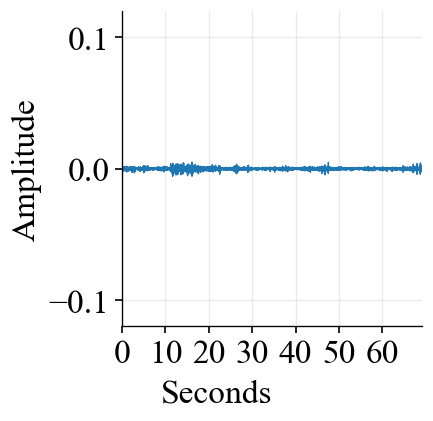

Event duration for example 0 (280126 · 3 km): 69.12 seconds


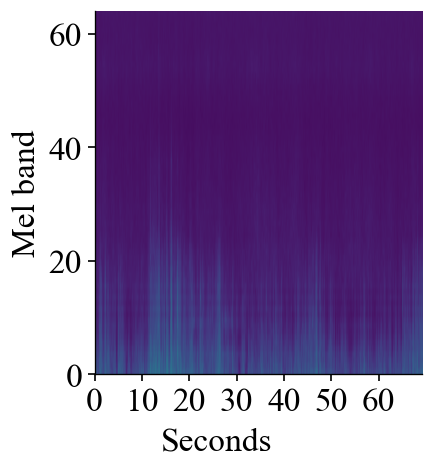

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_1_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_1_label_1_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\230226\loc_3_230226.wav
Preprocessing done. Spectrogram shape: (5854, 64)
Max amplitude for example 230226 · 3 km: 0.004399
Event duration for example 0 (230226 · 3 km): 58.56 seconds


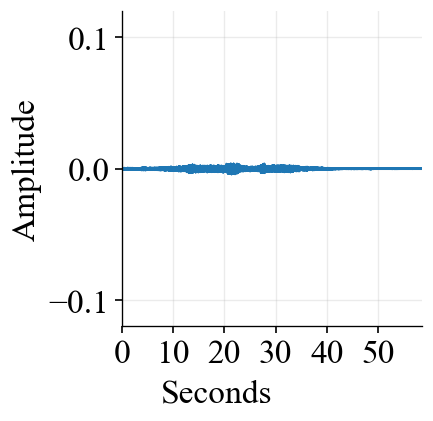

Event duration for example 0 (230226 · 3 km): 58.56 seconds


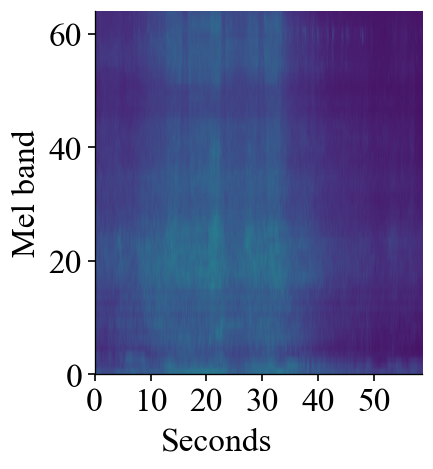

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_2_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_2_label_1_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\030326\loc_3_030326.wav
Preprocessing done. Spectrogram shape: (862, 64)
Max amplitude for example 030326 · 3 km: 0.000549
Event duration for example 0 (030326 · 3 km): 8.64 seconds


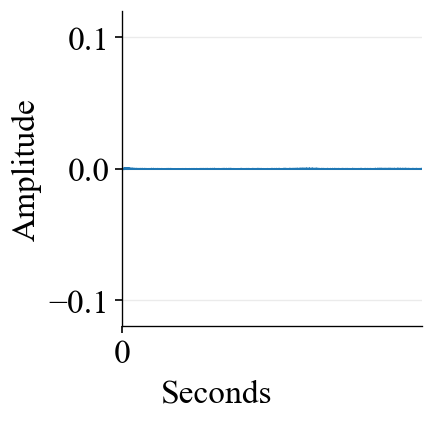

Event duration for example 0 (030326 · 3 km): 8.64 seconds


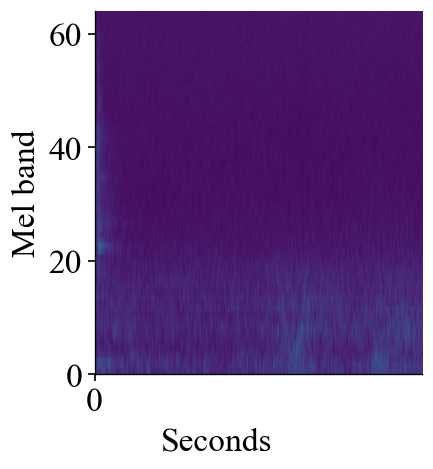

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_3_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_3_label_1_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\260326_part2\loc_1_260326_part2.wav
Preprocessing done. Spectrogram shape: (5854, 64)
Max amplitude for example 260326_part · 3 km: 0.001912
Event duration for example 0 (260326_part · 3 km): 58.56 seconds


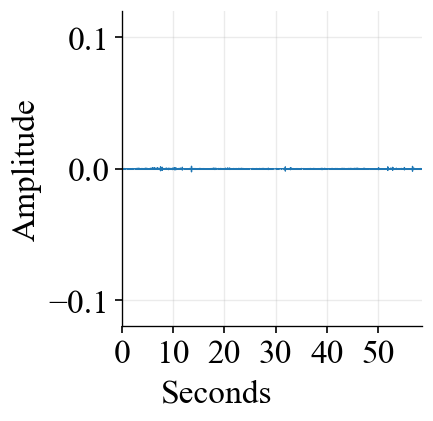

Event duration for example 0 (260326_part · 3 km): 58.56 seconds


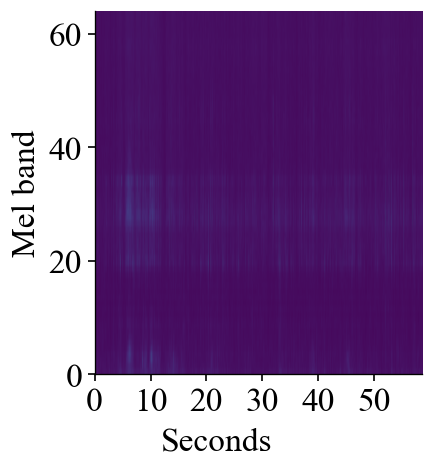

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_4_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_4_label_1_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\300925\gardemoen_300925.wav
Preprocessing done. Spectrogram shape: (5950, 64)
Max amplitude for example 300925 · 3 km: 0.005068
Event duration for example 0 (300925 · 3 km): 59.52 seconds


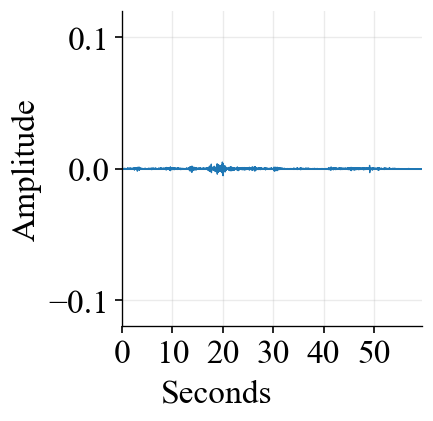

Event duration for example 0 (300925 · 3 km): 59.52 seconds


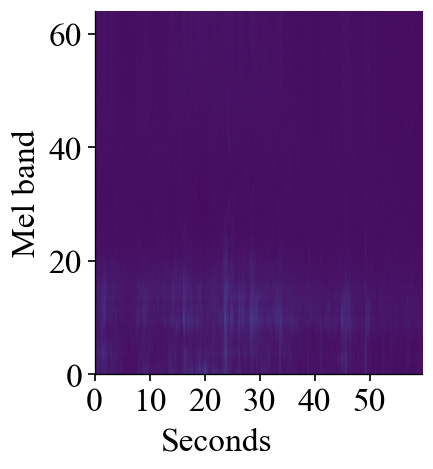

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_5_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_5_label_1_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C4BF6_2022-12-08_12-53-44_0_0.wav
Preprocessing done. Spectrogram shape: (4798, 64)
Max amplitude for example Fold 1: 0.001891
Event duration for example 0 (Fold 1): 48.00 seconds


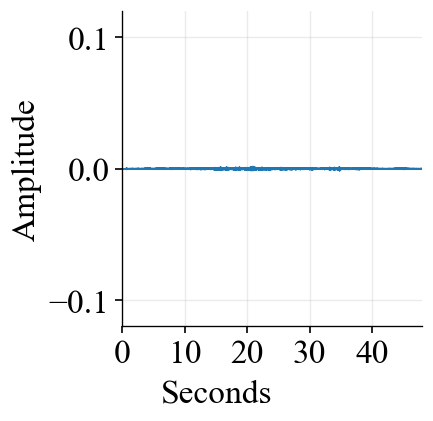

Event duration for example 0 (Fold 1): 48.00 seconds


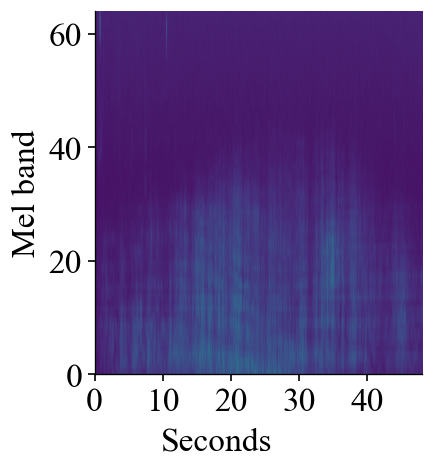

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold1_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold1_label_1_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C6B17_2022-12-12_17-45-34_0_1.wav
Preprocessing done. Spectrogram shape: (5598, 64)
Max amplitude for example Fold 2: 0.094063
Event duration for example 0 (Fold 2): 56.00 seconds


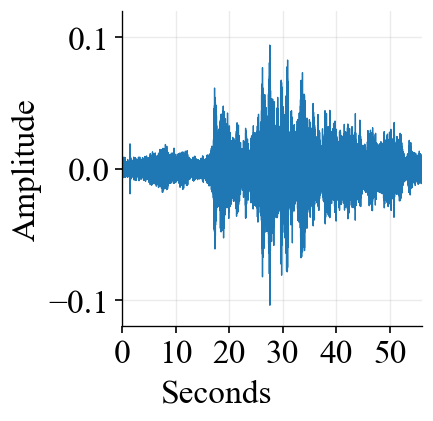

Event duration for example 0 (Fold 2): 56.00 seconds


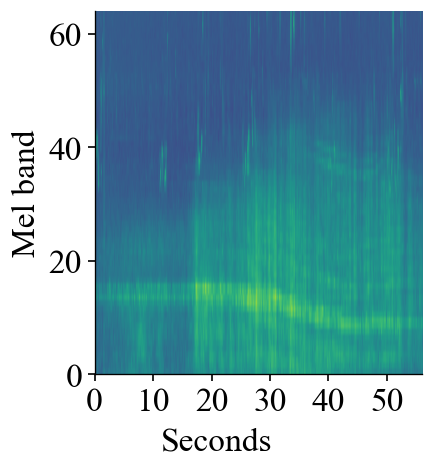

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold2_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold2_label_1_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C6C96_2023-04-05_11-47-51_0_1.wav
Preprocessing done. Spectrogram shape: (5998, 64)
Max amplitude for example Fold 3: 0.020892
Event duration for example 0 (Fold 3): 60.00 seconds


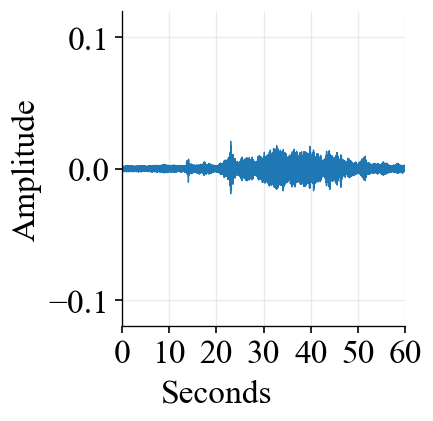

Event duration for example 0 (Fold 3): 60.00 seconds


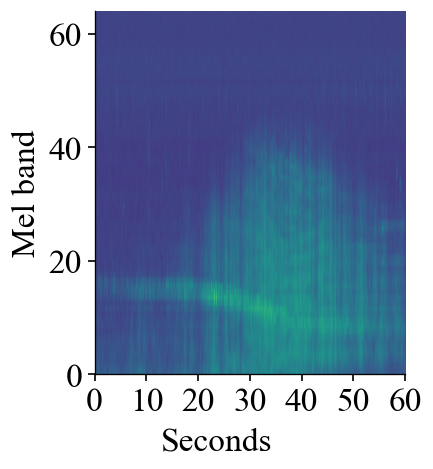

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold3_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold3_label_1_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C68B8_2023-04-15_11-08-46_0_1.wav
Preprocessing done. Spectrogram shape: (3998, 64)
Max amplitude for example Fold 4: 0.038368
Event duration for example 0 (Fold 4): 40.00 seconds


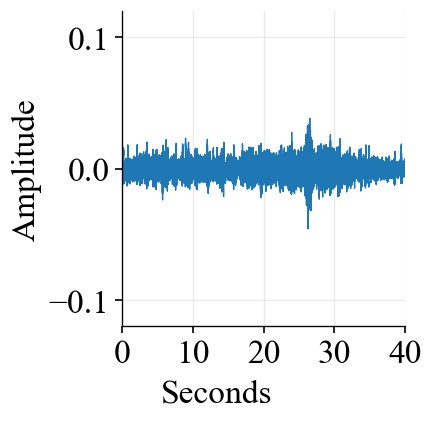

Event duration for example 0 (Fold 4): 40.00 seconds


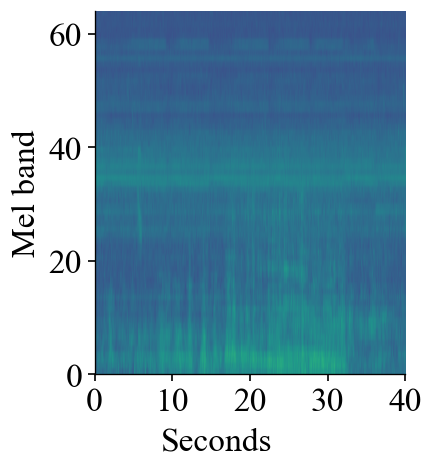

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold4_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold4_label_1_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C1CE4_2023-04-28_11-26-33_0_1.wav
Preprocessing done. Spectrogram shape: (5998, 64)
Max amplitude for example Fold 5: 0.013056
Event duration for example 0 (Fold 5): 60.00 seconds


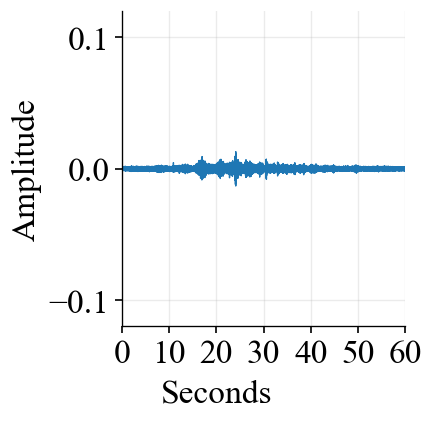

Event duration for example 0 (Fold 5): 60.00 seconds


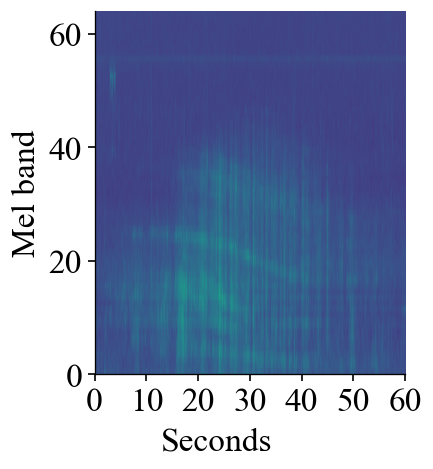

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold5_label_1_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold5_label_1_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\280126\loc_1_280126.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example 280126 · 3 km: 0.004059
Event duration for example 0 (280126 · 3 km): 15.00 seconds


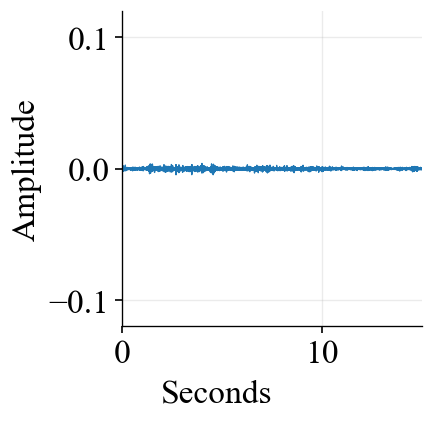

Event duration for example 0 (280126 · 3 km): 15.00 seconds


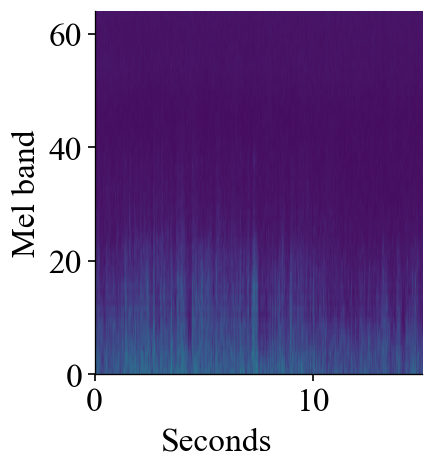

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_1_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_1_label_0_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\230226\loc_1_230226.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example 230226 · 3 km: 0.000112
Event duration for example 0 (230226 · 3 km): 15.00 seconds


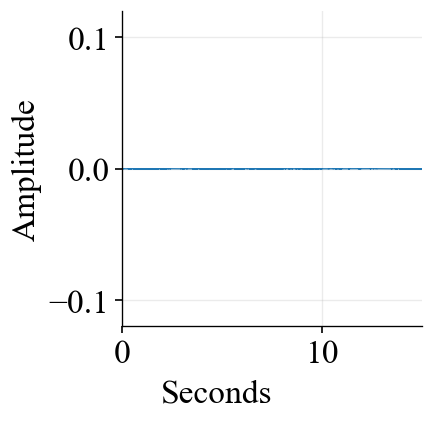

Event duration for example 0 (230226 · 3 km): 15.00 seconds


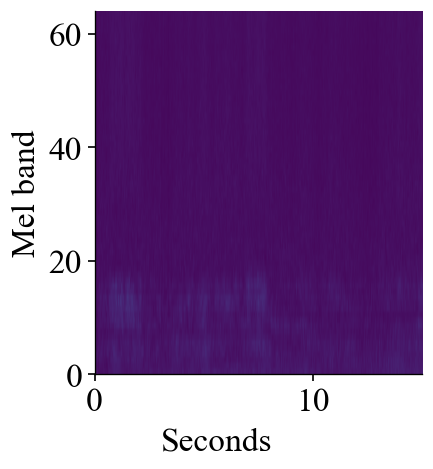

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_2_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_2_label_0_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\030326\loc_3_030326.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example 030326 · 3 km: 0.000065
Event duration for example 0 (030326 · 3 km): 15.00 seconds


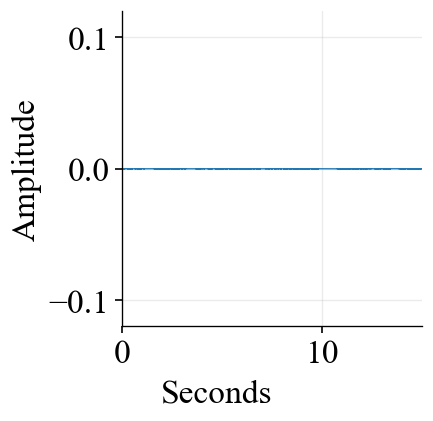

Event duration for example 0 (030326 · 3 km): 15.00 seconds


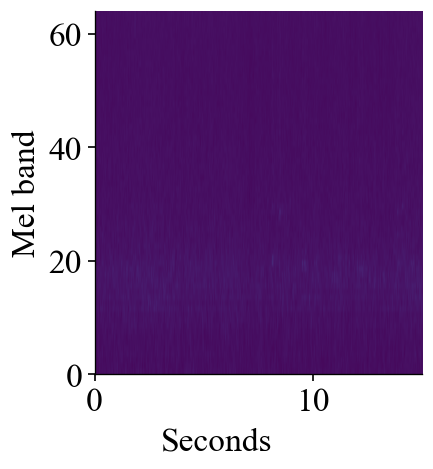

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_3_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_3_label_0_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\260326_part1\loc_1_260326_part1.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example 260326_part · 3 km: 0.000121
Event duration for example 0 (260326_part · 3 km): 15.00 seconds


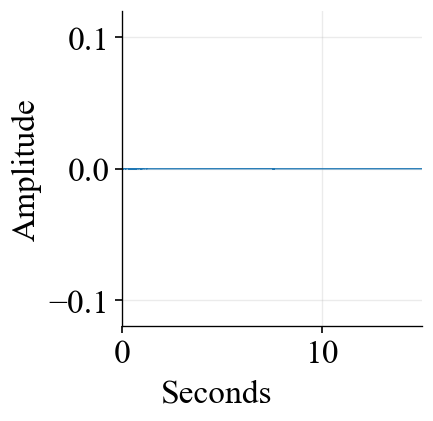

Event duration for example 0 (260326_part · 3 km): 15.00 seconds


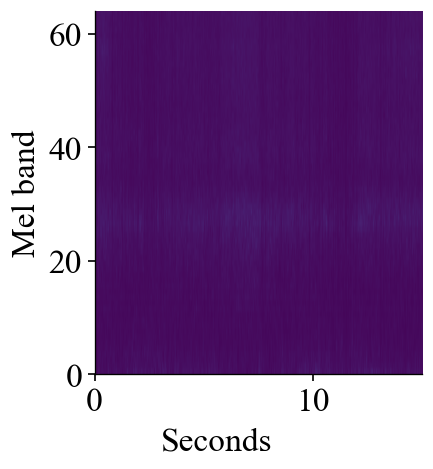

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_4_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_4_label_0_spectrogram.pdf
Processing and caching: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\dataset\Skatval\300925\gardemoen_300925.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example 300925 · 3 km: 0.000064
Event duration for example 0 (300925 · 3 km): 15.00 seconds


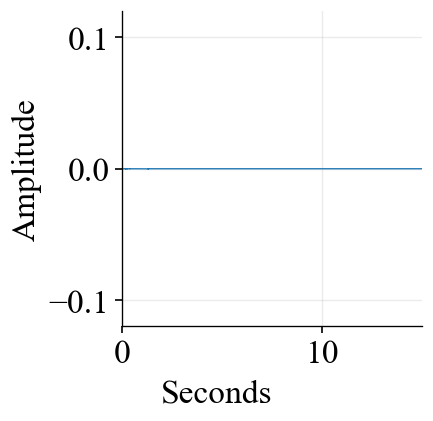

Event duration for example 0 (300925 · 3 km): 15.00 seconds


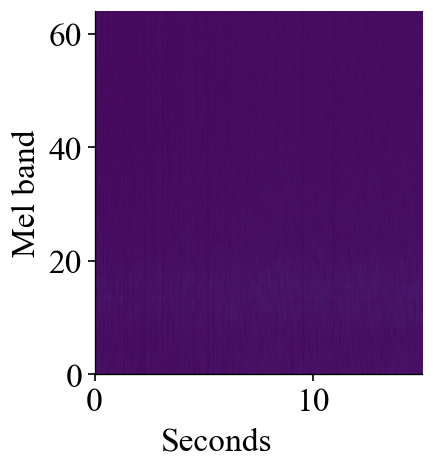

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_5_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\Stj_rdal_session_5_label_0_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C1CE4_2022-12-08_17-26-01_0_0.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example Fold 1: 0.001410
Event duration for example 0 (Fold 1): 15.00 seconds


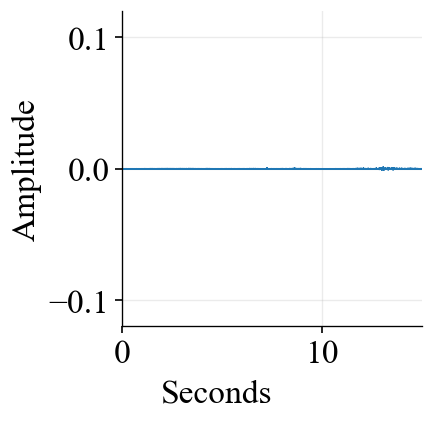

Event duration for example 0 (Fold 1): 15.00 seconds


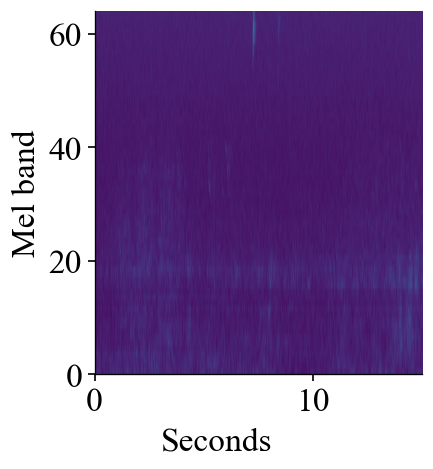

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold1_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold1_label_0_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C68CE_2022-12-15_14-53-46_0_1.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example Fold 2: 0.019488
Event duration for example 0 (Fold 2): 15.00 seconds


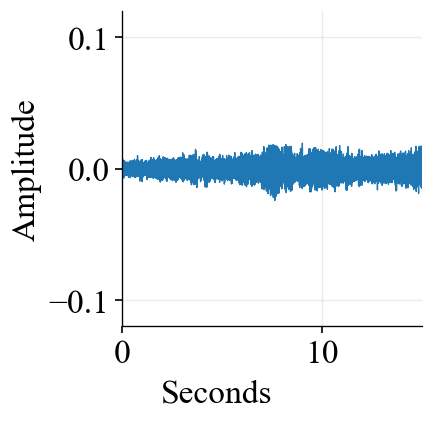

Event duration for example 0 (Fold 2): 15.00 seconds


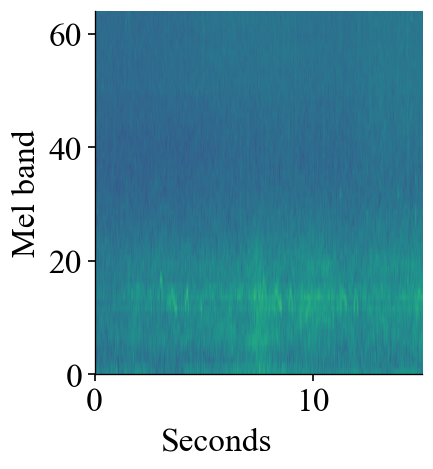

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold2_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold2_label_0_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C6C56_2023-04-06_17-55-04_0_1.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example Fold 3: 0.003626
Event duration for example 0 (Fold 3): 15.00 seconds


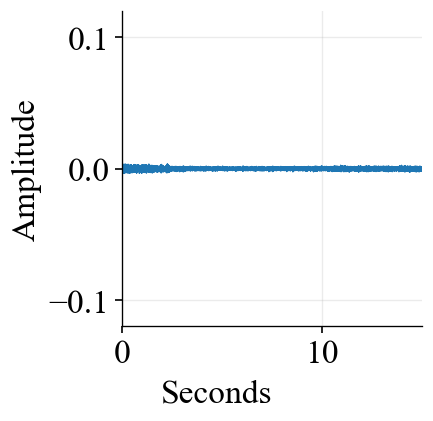

Event duration for example 0 (Fold 3): 15.00 seconds


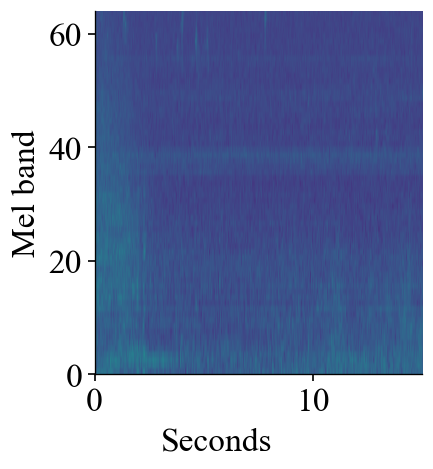

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold3_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold3_label_0_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C6CE6_2023-04-15_10-49-46_0_1.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example Fold 4: 0.018940
Event duration for example 0 (Fold 4): 15.00 seconds


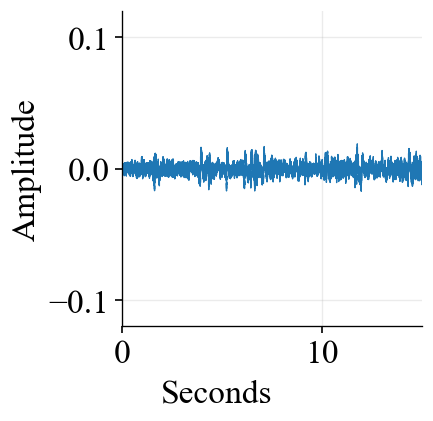

Event duration for example 0 (Fold 4): 15.00 seconds


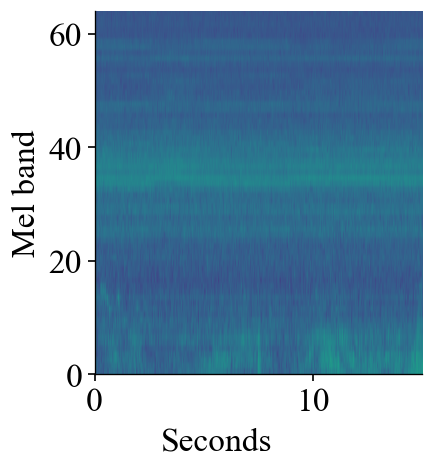

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold4_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold4_label_0_spectrogram.pdf
Processing and caching: C:\Users\imborhau\OneDrive - NTNU\Documents\Prosjektoppgave\AeroSonicDB-YPAD0523\data\raw\audio\1\7C6D2A_2023-04-25_16-47-19_0_1.wav
Preprocessing done. Spectrogram shape: (1498, 64)
Max amplitude for example Fold 5: 0.008095
Event duration for example 0 (Fold 5): 15.00 seconds


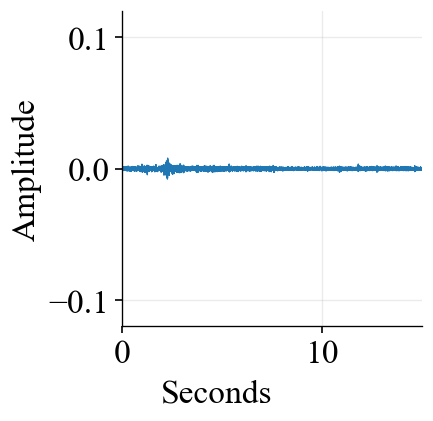

Event duration for example 0 (Fold 5): 15.00 seconds


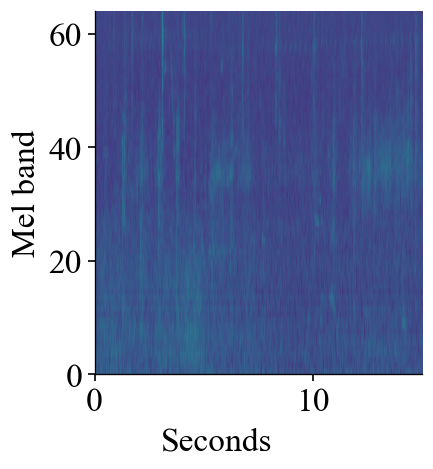

Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold5_label_0_waveform.pdf
Saved: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\AeroSonicDB_Fold5_label_0_spectrogram.pdf
Saved shared colorbar: c:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\figures\comparison_notebook\shared_intensity_bar.pdf


In [187]:
# Save individual waveform and spectrogram PDFs for each example
import re
#shared_spectrogram_limits = compute_shared_spectrogram_limits([*skatval_aircraft_examples, *aerosonic_aircraft_examples, *skatval_no_aircraft_examples, *aerosonic_no_aircraft_examples])
shared_spectrogram_limits = -7, 3


def _safe_filename(s: object) -> str:
    s = str(s)
    s = s.replace(' ', '_')
    s = re.sub(r'[^A-Za-z0-9_.-]', '_', s)
    return s


output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'comparison_notebook'
output_dir.mkdir(parents=True, exist_ok=True)


def save_individual_examples(examples: list[dict], default_palette: str = 'tab10') -> None:
    for example in examples:
        if example.get('dataset') == 'Skatval':
            session = example.get('session', example.get('group_label'))
            id_token = f"session_{SKATVAL_SESSION_MAP.get(session, session)}"
            palette_local = 'tab10'
        else:
            id_token = f"Fold{example.get('fold', example.get('group_label'))}"
            palette_local = 'tab20'

        if example.get('dataset') == 'Skatval':
            dataset_name = 'Stjørdal'
        elif example.get('dataset') == 'AeroSonicDB':
            dataset_name = 'AeroSonicDB'
        else:
            dataset_name = example.get('dataset', 'UnknownDataset')

        base = f"{dataset_name}_{id_token}_label_{example.get('class')}"
        base = _safe_filename(base)
        waveform_name = f"{base}_waveform.pdf"
        spectrogram_name = f"{base}_spectrogram.pdf"

        # Prepare panel data for this single example
        panel_data = _prepare_panel_data([example])

        print(f'Max amplitude for example {example["group_label"]}: {float(np.max(panel_data[0]["waveform"])):.6f}')


        # Save waveform and spectrogram PDFs (no colorbar here)
        _plot_waveform_row([example], panel_data, palette_local, waveform_name)
        _plot_spectrogram_row(
            [example],
            panel_data,
            palette_local,
            spectrogram_name,
            spectrogram_limits=shared_spectrogram_limits,
            show_colorbar=False,
        )

        print(f"Saved: {output_dir / waveform_name}")
        print(f"Saved: {output_dir / spectrogram_name}")


# Execute for both Skatval and AeroSonicDB examples
save_individual_examples(skatval_aircraft_examples, default_palette='tab10')
save_individual_examples(aerosonic_aircraft_examples, default_palette='tab20')
save_individual_examples(skatval_no_aircraft_examples, default_palette='tab10')
save_individual_examples(aerosonic_no_aircraft_examples, default_palette='tab20')

# Save one shared colorbar for all spectrograms
shared_colorbar_name = 'shared_intensity_bar.pdf'
_save_shared_colorbar_figure(shared_spectrogram_limits, shared_colorbar_name)
print(f'Saved shared colorbar: {PROJECT_ROOT / "outputs" / "figures" / "comparison_notebook" / shared_colorbar_name}')